In [5]:
import import_ipynb
import genetic_algorithm
import NSGA2
import simulated_annealing
from evaluators.knn_evaluator import evaluate_knn
from evaluators.random_forest_evaluator import evaluate_random_forest,evaluate_test
from evaluators.svc_evaluator import evaluate_svc
import pandas as pd
import numpy as np

Loading dataset oral toxicity

In [2]:
X_train_toxicity = pd.read_csv("../datasets/oral_toxicity/X_train.csv")
y_train_toxicity = pd.read_csv('../datasets/oral_toxicity/y_train.csv').to_numpy().ravel()
X_test_toxicity = pd.read_csv("../datasets/oral_toxicity/X_test.csv")
y_test_toxicity = pd.read_csv("../datasets/oral_toxicity/y_test.csv").to_numpy().ravel()

Loading dataset leukemia

In [3]:
X_train_leukemia = pd.read_csv("../datasets/leukemia/X_train.csv")
y_train_leukemia = pd.read_csv("../datasets/leukemia/y_train.csv").to_numpy().ravel()
X_test_leukemia = pd.read_csv("../datasets/leukemia/X_test.csv")
y_test_leukemia = pd.read_csv("../datasets/leukemia/y_test.csv").to_numpy().ravel()

Loading dataset Madelon

In [4]:
X_train_madelon = pd.read_csv("../datasets/madelon/X_train.csv")
y_train_madelon = pd.read_csv('../datasets/madelon/y_train.csv').to_numpy().ravel()
X_test_madelon = pd.read_csv("../datasets/madelon/X_test.csv")
y_test_madelon = pd.read_csv("../datasets/madelon/y_test.csv").to_numpy().ravel()

0.9280363223609533 0.0654296875
0.9178206583427923 0.041015625
0.9278093076049944 0.0439453125
0.9332576617480136 0.09375
0.9316685584562997 0.0859375
0.932349602724177 0.0888671875
0.9346197502837684 0.103515625
0.935754824063564 0.1455078125


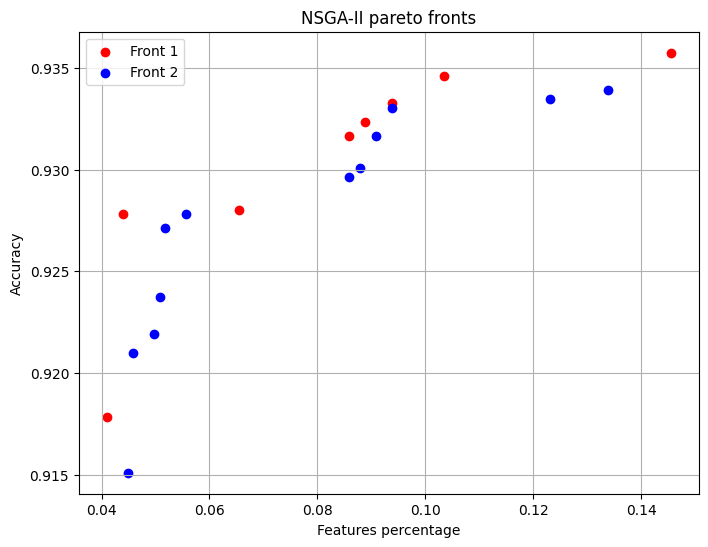

In [6]:
nsga = NSGA2.NSGA2(X_train_toxicity, y_train_toxicity, calc_accuracy_fn=evaluate_random_forest,
                   population_size=20, num_generations=3, feature_probability=0.05)
pareto = nsga.run()

In [7]:
sa =simulated_annealing.Simulated_Annealing(30,pareto[0].code,0.5,X_train_toxicity,y_train_toxicity,evaluate_random_forest)
sol, fitness,selected_percentage=sa.run()

In [8]:
fitness

0.933040179838252

In [9]:
selected_percentage

0.064453125

In [11]:
evaluate_test(sol,X_train_toxicity,y_train_toxicity,X_test_toxicity,y_test_toxicity,5)

Test accuracy: 0.9258710155670867
Report:
               precision    recall  f1-score   support

           0       0.94      0.98      0.96      2476
           1       0.60      0.29      0.39       222

    accuracy                           0.93      2698
   macro avg       0.77      0.64      0.68      2698
weighted avg       0.91      0.93      0.91      2698



In [6]:
ga = genetic_algorithm.GA( X_train_toxicity ,y_train_toxicity ,calc_accuracy_fn= evaluate_random_forest, population_size = 30, num_generations = 20, tournament_size=4, mutation_probability = 0.1,alpha = 0.1,elitism_size = 5,patience = 2,use_heuristic = False)
selected_features, fitness, history,population = ga.run()

No improvement for 2 generations


In [7]:
fitness

0.8652024355116189

In [8]:
evaluate_test(selected_features,X_train_toxicity,y_train_toxicity,X_test_toxicity,y_test_toxicity,5)

Test accuracy: 0.9266123054114158
Report:
               precision    recall  f1-score   support

           0       0.94      0.98      0.96      2476
           1       0.60      0.32      0.42       222

    accuracy                           0.93      2698
   macro avg       0.77      0.65      0.69      2698
weighted avg       0.91      0.93      0.92      2698



In [ ]:
#ga = genetic_algorithm.GA( X_train_leukemia ,y_train_leukemia,calc_accuracy_fn= evaluate_random_forest , population_size = 30, num_generations = 20, tournament_size=4, mutation_probability = 0.1,alpha = 0.1,elitism_size = 5,patience = 10,use_heuristic = True)
#selected_features, fitness, history, population = ga.run()

In [ ]:
#evaluate_knn(selected_features,X_train_leukemia,y_train_leukemia,X_test_leukemia,y_test_leukemia)

In [ ]:
#fitness

In [ ]:
#ga = genetic_algorithm.GA( X_train_leukemia ,y_train_leukemia,calc_accuracy_fn= evaluate_random_forest , population_size = 30, num_generations = 50, tournament_size=4, mutation_probability = 0.1,alpha = 0.1,elitism_size = 3,patience = 10,use_heuristic = True)
#selected_features, fitness, history,population = ga.run()

In [ ]:
#fitness

In [ ]:
#evaluate_random_forest(selected_features,X_train_leukemia,y_train_leukemia,X_test_leukemia,y_test_leukemia)

In [16]:
ga = genetic_algorithm.GA( X_train_madelon ,y_train_madelon,calc_accuracy_fn= evaluate_random_forest , population_size = 150, num_generations = 30, tournament_size=5, mutation_probability = 0.1,alpha = 0.5,elitism_size = 5,patience = 3,use_heuristic = True)
selected_features, fitness, history,population = ga.run()

No improvement for 3 generations


In [20]:
fitness

0.8377142857142856

In [21]:
sum(selected_features)

13

In [22]:
evaluate_test(selected_features,X_train_madelon,y_train_madelon,X_test_madelon,y_test_madelon,5)

Test accuracy: 0.7183333333333334
Report:
               precision    recall  f1-score   support

           0       0.71      0.75      0.73       300
           1       0.73      0.69      0.71       300

    accuracy                           0.72       600
   macro avg       0.72      0.72      0.72       600
weighted avg       0.72      0.72      0.72       600



In [ ]:
def most_frequent_features(population):
    solutions = np.array([individual.code for individual in population])
    counts = solutions.sum(axis=0)
    ranked = np.argsort(counts)[::-1]
    return counts,ranked

In [ ]:
#most_frequent_features(population) #da li da je ovo koristi dalje mozda vizuelizovati 